## Part 2: Topic Modeling with BERTopic

**Project:** Management Accounting Research — Systematic Literature Review  
**Input:** `papers_preprocessed.csv` (produced by `01_Data.ipynb`)  

This notebook applies **BERTopic** to the preprocessed corpus of accounting journal articles. BERTopic combines sentence-transformer embeddings with UMAP dimensionality reduction and HDBSCAN clustering to produce coherent, human-interpretable topics. The pipeline is fully reproducible: embeddings are cached to disk and all model parameters are explicitly documented.

---

### Output files produced by this notebook

| File | Description |
|---|---|
| `embeddings.npy` | Cached sentence embeddings (skip recomputation on reruns) |
| `papers_with_topics.csv` | Full dataset with `topic_id` and `topic_probability` columns |
| `fig_topic_barchart.png/.html` | Top 20 topics by paper count |
| `fig_topic_keywords.png` | Per-topic c-TF-IDF keyword scores (top 10 topics) |
| `fig_topic_map.png/.html` | 2D UMAP document map coloured by topic |
| `fig_topics_over_time.png/.html` | Topic trajectories 2021–2026 |
| `topic_labeling_input.txt` | Structured input for LLM-assisted topic labeling |

## Notebook Structure

| Step | Content |
|---|---|
| **Step 10** | Load Data & Choose Corpus |
| **Step 11** | Sentence Embeddings |
| **Step 12** | BERTopic Configuration & Model Run (incl. sensitivity analysis) |
| **Step 13** | Topic Overview — 13a: Manual Split — 13b: Noise Inspection — 13c: Topic Validation |
| **Step 14** | Visualizations |
| **Step 16** | AI Labeling Preparation |
| **Step 17** | Final Summary |

**Primary corpus:** MA_journals (MAR, JMAR, JOMAC), 2021–2026, N=314  
**Model:** BERTopic with all-MiniLM-L6-v2, min_cluster_size=8, min_samples=1  
**Final topics:** 12 (incl. manual split of Topic 2)  
**Noise:** 40 papers (12.7%)


---

### Install & Import Dependencies

The cell below installs all required packages silently. Re-running it is safe — pip skips packages that are already installed.

In [1]:
import os
import re
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Imports successful.")

c:\Users\Sören Schlißke\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful.


---

## Step 10 — Load Data & Choose Corpus

Select the analysis corpus by setting `CORPUS_MODE` to one of four options:

| Mode | Source file | Description |
|---|---|---|
| `'full'` | `papers_preprocessed.csv` | All articles that passed document-type and abstract filters — baseline for field overview |
| `'MA_flag'` | `papers_preprocessed.csv` | Articles flagged as management-accounting-relevant via keyword screening (`is_management_accounting == True`) across **all journals** — **PRIMARY ANALYSIS CORPUS** |
| `'MA_journals'` | `papers_MA_journals.csv` | Articles from the three specialist MA journals only (MAR, JMAR, JOMAC) regardless of keyword flag |
| `'MA_strict'` | `papers_MA_strict.csv` | Articles that are **both** from the three MA journals **and** keyword-flagged — most focused corpus |

> **Primary analysis:** `MA_flag` is the default. It captures management-accounting-relevant papers across the full journal set, giving broader coverage than `MA_journals` while still filtering for topical relevance.  
> Change `CORPUS_MODE` below to switch between corpora. The embeddings cache is automatically invalidated when the mode changes.

Documents shorter than 50 characters in `text_for_modeling` are dropped as they cannot produce meaningful embeddings.

In [2]:
# ── Corpus mode — change this to switch analysis corpus ────────────────────────
CORPUS_MODE = 'MA_journals'   
#   Options:
#   'full'        → all articles from all journals  (papers_preprocessed.csv)
#   'MA_flag'     → MA-flagged articles across all journals (is_management_accounting == True)
#   'MA_journals' → only articles from MAR, JMAR, JOMAC   (papers_MA_journals.csv)
#   'MA_strict'   → MA-flagged AND from one of the 3 MA journals (papers_MA_strict.csv)

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
EMBEDDINGS_FILE = "embeddings.npy"
EMBEDDINGS_MODE_FILE = "embeddings_mode.txt"

# ── Select source file based on mode ──────────────────────────────────────────
_CORPUS_FILES = {
    "full":        "papers_preprocessed.csv",
    "MA_flag":     "papers_preprocessed.csv",
    "MA_journals": "papers_MA_journals.csv",
    "MA_strict":   "papers_MA_strict.csv",
}

if CORPUS_MODE not in _CORPUS_FILES:
    raise ValueError(f"Unknown CORPUS_MODE '{CORPUS_MODE}'. "
                     f"Choose from: {list(_CORPUS_FILES)}")

DATA_FILE = _CORPUS_FILES[CORPUS_MODE]

# ── Load ───────────────────────────────────────────────────────────────────────
df_all = pd.read_csv(DATA_FILE, dtype=str)
df_all["Year"] = pd.to_numeric(df_all["Year"], errors="coerce")
df_all["is_management_accounting"] = df_all["is_management_accounting"].map(
    {"True": True, "False": False, True: True, False: False}
)

print(f"Loaded {len(df_all):,} rows from {DATA_FILE}")

# ── Select corpus rows ─────────────────────────────────────────────────────────
if CORPUS_MODE == "MA_flag":
    df_model = df_all[df_all["is_management_accounting"] == True].copy()
else:
    # 'full', 'MA_journals', 'MA_strict' — file is already pre-filtered
    df_model = df_all.copy()

# Drop rows with missing or very short text_for_modeling
df_model["text_for_modeling"] = df_model["text_for_modeling"].fillna("").str.strip()
df_model = df_model[df_model["text_for_modeling"].str.len() >= 50].copy()
df_model.reset_index(drop=True, inplace=True)

docs = df_model["text_for_modeling"].tolist()

# ── Confirmation ───────────────────────────────────────────────────────────────
journals_present = sorted(df_model["Source title"].dropna().unique().tolist())
year_min = int(df_model["Year"].min()) if df_model["Year"].notna().any() else "N/A"
year_max = int(df_model["Year"].max()) if df_model["Year"].notna().any() else "N/A"

print(f"\nCorpus mode       : {CORPUS_MODE}")
print(f"Papers loaded     : {len(docs):,}")
print(f"Journals represented:")
for j in journals_present:
    print(f"  • {j}")
print(f"Year range        : {year_min} – {year_max}")

Loaded 314 rows from papers_MA_journals.csv

Corpus mode       : MA_journals
Papers loaded     : 314
Journals represented:
  • Journal of Management Accounting Research
  • Journal of Management Control
  • Management Accounting Research
Year range        : 2021 – 2026


---

## Step 11 — Sentence Embeddings

We encode every document using **`all-MiniLM-L6-v2`**, a lightweight but high-quality sentence-transformer model that maps variable-length text to a 384-dimensional dense vector.

> **Why `text_for_modeling` and not `abstract_clean`?**  
> BERTopic relies on a transformer's contextual language understanding, not bag-of-words statistics. The model reads semantic meaning from complete, natural sentences — punctuation, articles, and word order all contribute to the embedding. Feeding it the stopword-stripped `abstract_clean` would degrade embedding quality. The cleaned text is reserved for TF-IDF-based keyword extraction (inside BERTopic's `CountVectorizer` component), where noise reduction is beneficial.

Embeddings are cached to `embeddings.npy`. On subsequent runs the file is loaded directly, saving several minutes of computation.

In [3]:
# ── Check embeddings cache validity ───────────────────────────────────────────
# The cache is valid only when both the .npy file exists AND the mode recorded
# in embeddings_mode.txt matches the current CORPUS_MODE.
embeddings = None

if os.path.exists(EMBEDDINGS_FILE) and os.path.exists(EMBEDDINGS_MODE_FILE):
    with open(EMBEDDINGS_MODE_FILE, "r", encoding="utf-8") as _f:
        cached_mode = _f.read().strip()
    if cached_mode == CORPUS_MODE:
        embeddings = np.load(EMBEDDINGS_FILE)
        print(f"Loaded cached embeddings from '{EMBEDDINGS_FILE}'  [mode: {cached_mode}]")
        if embeddings.shape[0] != len(docs):
            print(
                f"  WARNING: cache has {embeddings.shape[0]} rows but corpus has {len(docs)} docs. "
                "Recomputing embeddings."
            )
            embeddings = None
    else:
        print(f"Corpus mode changed ({cached_mode!r} → {CORPUS_MODE!r}). Recomputing embeddings.")
else:
    print("No valid embeddings cache found. Computing from scratch.")

# ── Compute if needed ─────────────────────────────────────────────────────────
if embeddings is None:
    print(f"Computing embeddings with '{EMBEDDING_MODEL}' ...")
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)
    embeddings = sentence_model.encode(
        docs,
        show_progress_bar=True,
        batch_size=64
    )
    np.save(EMBEDDINGS_FILE, embeddings)
    with open(EMBEDDINGS_MODE_FILE, "w", encoding="utf-8") as _f:
        _f.write(CORPUS_MODE)
    print(f"Embeddings saved to '{EMBEDDINGS_FILE}'")
    print(f"Mode recorded in '{EMBEDDINGS_MODE_FILE}'  [mode: {CORPUS_MODE}]")

print(f"\nEmbedding shape : {embeddings.shape}  ({embeddings.shape[0]} docs × {embeddings.shape[1]} dims)")

Loaded cached embeddings from 'embeddings.npy'  [mode: MA_journals]

Embedding shape : (314, 384)  (314 docs × 384 dims)


---

## Step 12 — BERTopic Configuration & Model Run

BERTopic is a modular pipeline; each component is configured explicitly:

| Component | Role | Key parameters |
|---|---|---|
| **UMAP** | Dimensionality reduction | `n_neighbors=15` balances local vs. global structure; `n_components=5` retains enough signal for HDBSCAN; `metric='cosine'` is appropriate for normalised text embeddings; `min_dist=0.0` produces tighter clusters |
| **HDBSCAN** | Density-based clustering | `min_cluster_size=8` sets the minimum papers per topic; `min_samples=1` controls noise labelling aggressiveness; `prediction_data=True` enables soft-cluster probabilities |
| **CountVectorizer** | c-TF-IDF keyword extraction | `ngram_range=(1,2)` captures important bigrams (e.g. *performance measurement*); `min_df=3` drops hapax legomena |
| **BERTopic** | Orchestration | `top_n_words=10` per topic; `verbose=True` for progress reporting |

The model is fit in one call; `topics` is a list of integer topic IDs (−1 = noise) and `probs` contains the soft-assignment probabilities.

### 12a — Initial Model Parameters & Fitting

In [4]:
# ── Sub-model configuration ────────────────────────────────────────────────────
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=14,
    min_samples=4,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

In [5]:
# ── Fit ───────────────────────────────────────────────────────────────────────
topics, probs = topic_model.fit_transform(docs, embeddings)

# Flatten probs if HDBSCAN returns a matrix (soft-clustering)
if isinstance(probs, np.ndarray) and probs.ndim == 2:
    topic_probs = probs.max(axis=1)
else:
    topic_probs = np.array(probs) if not isinstance(probs, np.ndarray) else probs

# ── Summary ───────────────────────────────────────────────────────────────────
unique_topics   = sorted(set(topics))
n_topics        = len([t for t in unique_topics if t != -1])
n_noise         = sum(1 for t in topics if t == -1)

print(f"\nTopics found (excl. noise) : {n_topics}")
print(f"Noise papers (topic = -1)  : {n_noise:,} ({n_noise / len(topics) * 100:.1f}%)")

print("\nTop 5 largest topics:")
topic_info = topic_model.get_topic_info()
top5 = topic_info[topic_info["Topic"] != -1].head(5)
for _, row in top5.iterrows():
    kws = ", ".join([w for w, _ in topic_model.get_topic(row["Topic"])[:5]])
    print(f"  Topic {row['Topic']:>3d} | {row['Count']:>4} papers | {kws}")

2026-04-08 18:32:15,544 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-08 18:32:22,987 - BERTopic - Dimensionality - Completed ✓
2026-04-08 18:32:22,987 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-08 18:32:23,013 - BERTopic - Cluster - Completed ✓
2026-04-08 18:32:23,019 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-08 18:32:23,091 - BERTopic - Representation - Completed ✓



Topics found (excl. noise) : 4
Noise papers (topic = -1)  : 35 (11.1%)

Top 5 largest topics:
  Topic   0 |  107 papers | management, control, accounting, performance, study
  Topic   1 |   99 papers | performance, employees, information, managers, effort
  Topic   2 |   53 papers | firms, compensation, governance, executive, association
  Topic   3 |   20 papers | cost, stickiness, supply, firms, cost behavior


### 12b — Sensitivity Analysis (Hyperparameter Selection)

**Grid:** 3 × 2 × 2 = 12 combinations. Embeddings are reused from cache so each fit takes only a few seconds.  

In [6]:
import itertools

# ── Parameter grid ────────────────────────────────────────────────────────────
# Each combination runs a fresh BERTopic fit on the cached embeddings.
GRID = {
    "min_samples"             : [1, 2, 3],          # HDBSCAN noise sensitivity
    "cluster_selection_method": ["eom", "leaf"],     # eom=flat big, leaf=granular
    "n_neighbors"             : [10, 15],            # UMAP locality vs. globality
}
# Fixed across all runs (same as primary model)
_MCS   = 8     # min_cluster_size
_MINDF = 3     # CountVectorizer min_df

print(f"Running {len(list(itertools.product(*GRID.values())))} configurations "
      f"on {len(docs)} documents (embeddings reused from cache)...\n")

_rows = []
for min_samp, csm, nn in itertools.product(
        GRID["min_samples"],
        GRID["cluster_selection_method"],
        GRID["n_neighbors"]):

    _tm = BERTopic(
        umap_model=UMAP(n_neighbors=nn, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=_MCS, min_samples=min_samp,
                              metric="euclidean",
                              cluster_selection_method=csm,
                              prediction_data=True),
        vectorizer_model=CountVectorizer(ngram_range=(1, 2),
                                         stop_words="english", min_df=_MINDF),
        top_n_words=10,
        verbose=False,
    )
    _t, _ = _tm.fit_transform(docs, embeddings)

    n_t   = len([t for t in set(_t) if t != -1])
    n_n   = sum(1 for t in _t if t == -1)
    pct_n = n_n / len(_t) * 100
    vc    = pd.Series(_t).value_counts()
    largest = int(vc[vc.index != -1].max()) if n_t > 0 else 0

    _rows.append(dict(n_neighbors=nn, min_samples=min_samp, csm=csm,
                      topics=n_t, noise=n_n,
                      noise_pct=round(pct_n, 1), largest=largest))

df_grid = (pd.DataFrame(_rows)
             .sort_values(["noise_pct", "topics"], ascending=[True, False])
             .reset_index(drop=True))

print("Grid search results (sorted by noise %):")
print(df_grid.rename(columns={"n_neighbors": "n_nbrs", "min_samples": "min_samp",
                               "noise_pct": "noise_%", "topics": "Topics",
                               "noise": "Noise", "largest": "Largest_topic"})
             .to_string(index=False))

# Baseline for comparison
n_base   = sum(1 for t in topics if t == -1)
pct_base = n_base / len(topics) * 100
print(f"\nBaseline (current model): {len([t for t in set(topics) if t != -1])} topics, "
      f"{n_base} noise ({pct_base:.1f}%)")

# ── Best configuration ────────────────────────────────────────────────────────
best = df_grid.iloc[0]
print(f"\n{'─'*60}")
print(f"Best config: n_neighbors={int(best.n_neighbors)}, "
      f"min_samples={int(best.min_samples)}, csm='{best.csm}'")
print(f"  → {int(best.topics)} topics | {int(best.noise)} noise ({best.noise_pct}%)")

Running 12 configurations on 314 documents (embeddings reused from cache)...

Grid search results (sorted by noise %):
 n_nbrs  min_samp  csm  Topics  Noise  noise_%  Largest_topic
     15         1  eom      11     40     12.7             60
     10         3  eom      10     47     15.0             88
     15         2  eom      11     50     15.9             59
     10         2  eom      12     51     16.2             46
     10         1  eom      14     57     18.2             43
     15         3  eom      10     70     22.3             56
     10         2 leaf      14     79     25.2             40
     10         1 leaf      16     80     25.5             25
     15         1 leaf      15     80     25.5             37
     10         3 leaf      12     88     28.0             34
     15         2 leaf      13     99     31.5             35
     15         3 leaf      12    119     37.9             30

Baseline (current model): 4 topics, 35 noise (11.1%)

────────────────────

> **Parameter selection:** Based on the sensitivity analysis above, `min_cluster_size=8`, `min_samples=1` was selected as it yields 11 interpretable topics with an acceptable noise rate of 12.7%. See methodology section 3.5.

### 12c — Final Model Configuration

The sub-models below use the parameters selected in 12b. All settings are fixed for the main analysis run.

In [7]:
# ── Sub-model configuration ────────────────────────────────────────────────────
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=8,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

### 12d — Fit and Transform

The model is fit on the corpus documents using the pre-computed sentence embeddings. Soft-cluster probabilities are flattened to a single confidence score per paper.

In [8]:
# ── Fit ───────────────────────────────────────────────────────────────────────
topics, probs = topic_model.fit_transform(docs, embeddings)

# Flatten probs if HDBSCAN returns a matrix (soft-clustering)
if isinstance(probs, np.ndarray) and probs.ndim == 2:
    topic_probs = probs.max(axis=1)
else:
    topic_probs = np.array(probs) if not isinstance(probs, np.ndarray) else probs

# ── Summary ───────────────────────────────────────────────────────────────────
unique_topics   = sorted(set(topics))
n_topics        = len([t for t in unique_topics if t != -1])
n_noise         = sum(1 for t in topics if t == -1)

print(f"\nTopics found (excl. noise) : {n_topics}")
print(f"Noise papers (topic = -1)  : {n_noise:,} ({n_noise / len(topics) * 100:.1f}%)")

print("\nTop 5 largest topics:")
topic_info = topic_model.get_topic_info()
top5 = topic_info[topic_info["Topic"] != -1].head(5)
for _, row in top5.iterrows():
    kws = ", ".join([w for w, _ in topic_model.get_topic(row["Topic"])[:5]])
    print(f"  Topic {row['Topic']:>3d} | {row['Count']:>4} papers | {kws}")

2026-04-08 18:32:30,141 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-08 18:32:30,585 - BERTopic - Dimensionality - Completed ✓
2026-04-08 18:32:30,585 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-08 18:32:30,600 - BERTopic - Cluster - Completed ✓
2026-04-08 18:32:30,602 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-08 18:32:30,661 - BERTopic - Representation - Completed ✓



Topics found (excl. noise) : 11
Noise papers (topic = -1)  : 40 (12.7%)

Top 5 largest topics:
  Topic   0 |   60 papers | firms, ceos, compensation, internal, ceo
  Topic   1 |   51 papers | performance, effort, information, team, managers
  Topic   2 |   37 papers | management, accounting, management accounting, research, business
  Topic   3 |   25 papers | pay, transparency, employees, dispersion, performance
  Topic   4 |   24 papers | cost, stickiness, firms, supply, investment


---

## Step 13 — Topic Overview Table

We build a human-readable topic summary table and merge topic assignments back into the main dataframe. The result is saved as `papers_with_topics.csv` for use in the analysis sections of the paper.

In [9]:
# ── Topic overview dataframe ───────────────────────────────────────────────────
topic_info = topic_model.get_topic_info().copy()

def get_top_keywords(topic_id, n=7):
    try:
        words = topic_model.get_topic(int(topic_id))
    except (ValueError, TypeError):
        words = []
    if not words:
        return ""
    return ", ".join([w for w, _ in words[:n]])

topic_info["top_keywords"] = topic_info["Topic"].apply(
    lambda t: get_top_keywords(t) if t != -1 else "[noise]"
)

topic_overview = (
    topic_info[topic_info["Topic"] != -1]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
    [["Topic", "Count", "top_keywords"]]
)

print(f"Topic overview ({len(topic_overview)} topics):")
pd.set_option("display.max_colwidth", 120)
display(topic_overview)

# ── Merge back into df_model ───────────────────────────────────────────────────
df_model["topic_id"]          = topics
df_model["topic_probability"] = topic_probs

# Add keyword label for convenience
kw_map = {row["Topic"]: row["top_keywords"] for _, row in topic_info.iterrows()}
df_model["topic_keywords"] = df_model["topic_id"].map(kw_map).fillna("[noise]")

df_model.to_csv("papers_with_topics.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved papers_with_topics.csv  ({len(df_model):,} rows)")


Topic overview (11 topics):


,Topic,Count,top_keywords
0,0,60,"firms, ceos, compensation, internal, ceo, association, executive"
1,1,51,"performance, effort, information, team, managers, employees, feedback"
2,2,37,"management, accounting, management accounting, research, business, accountants, role"
3,3,25,"pay, transparency, employees, dispersion, performance, workers, ai"
4,4,24,"cost, stickiness, firms, supply, investment, cost behavior, supply chain"
5,5,22,"risk, management, control, organizational, organisational, culture, management control"
6,6,17,"sustainability, control, environmental, systems, innovation, management, use"
7,7,11,"budget, budgets, creativity, budgeting, diagnostic use, performance, individual"
8,8,10,"subjective, evaluation, evaluations, performance, procedural, subordinates, numerical"
9,9,9,"trust, control, employees, partners, management control, controls, experience"



Saved papers_with_topics.csv  (314 rows)


### 13a — Topic Validation

The original BERTopic output yields **11 named topics** (Topics 0–10) plus a noise class.
Following a deliberate methodological decision, **no manual splits are applied**: all 11 clusters are retained as-is.

Two topics warrant explicit comment:

- **Topic 0** (n=60, largest cluster): Spans executive compensation/incentive contracting and corporate governance mechanisms. This semantic breadth is acknowledged in the results narrative as a broad cluster straddling two sub-streams.
- **Topic 2** (n=37): Covers both the evolving role/identity of management accountants and digitalization of the finance function. Similarly flagged as a broad cluster in the results.

Retaining original BERTopic assignments preserves full methodological transparency: the clustering reflects the model's data-driven grouping without researcher-imposed post-hoc restructuring.


In [10]:
# ── Create topic_id_revised column (mirrors topic_id — no manual splits applied) ──
# This column is retained for CSV compatibility with prior versions.
df_model['topic_id_revised'] = df_model['topic_id'].astype(str)

n_assigned = (df_model['topic_id'] != -1).sum()
n_noise    = (df_model['topic_id'] == -1).sum()
print(f"Topics retained (original BERTopic): {df_model['topic_id'].nunique() - 1}")
print(f"Assigned papers: {n_assigned} ({n_assigned/len(df_model)*100:.1f}%)")
print(f"Noise papers:    {n_noise}    ({n_noise/len(df_model)*100:.1f}%)")


Topics retained (original BERTopic): 11
Assigned papers: 274 (87.3%)
Noise papers:    40    (12.7%)


In [11]:
# ── No topic_id overwrite required ─────────────────────────────────────────────
# Manual splits have been removed. topic_id retains the original integer BERTopic
# assignments (0–10, -1) set in cell 20. topic_overview is already correct.
print('topic_id retains original BERTopic integer assignments (no manual splits).')
print(f'topic_overview: {len(topic_overview)} topics')


topic_id retains original BERTopic integer assignments (no manual splits).
topic_overview: 11 topics


---

### 13b — Noise Inspection

Papers assigned to **topic −1** were not clustered by HDBSCAN because they did not lie in a sufficiently dense region of the embedding space. Reviewing these papers alongside the topic overview helps identify whether any coherent hidden sub-topic should be split off.

> **Why noise is methodologically preferable to forced assignment (LDA-style):**  
> Latent Dirichlet Allocation assigns every document to at least one topic regardless of whether a natural cluster exists. HDBSCAN with a noise label is more honest: papers that genuinely span multiple topics or represent niche, low-frequency themes are flagged rather than distorted. This produces cleaner, more interpretable topics at the cost of some coverage.


In [12]:
df_noise = df_model[df_model["topic_id"] == -1][["Title", "Source title", "Year"]]

print(f"Total noise papers: {len(df_noise):,}  ({len(df_noise) / len(df_model) * 100:.1f}% of corpus)\n")

sample_size = min(10, len(df_noise))
print(f"Random sample of {sample_size} noise papers:")
display(
    df_noise.sample(sample_size, random_state=42).reset_index(drop=True)
)


Total noise papers: 40  (12.7% of corpus)

Random sample of 10 noise papers:


,Title,Source title,Year
0,The Effects of Top Management Team Age Diversity During a Crisis: Evidence from the COVID-19 Pandemic,Journal of Management Accounting Research,2024
1,The effect of within-domain task changes and compensation contracts on performance,Management Accounting Research,2025
2,Revising the theory behind corporate governance and management control: A reflection and roadmap,Management Accounting Research,2024
3,Necessity: The mother of invention? the tension between management control and creativity: Lessons from apollo 13,Journal of Management Accounting Research,2021
4,The influence of organizational structure on value-based management sophistication,Management Accounting Research,2022
5,How senior managers use interactive control to manage strategic uncertainties: An attention-based view,Management Accounting Research,2024
6,"The use of management controls in different cultural regions: an empirical study of Anglo-Saxon, Germanic and Nordic...",Journal of Management Control,2022
7,Does a Cooperative Values Statement Impact Predicted Transfer Prices?,Journal of Management Accounting Research,2025
8,The link between corporate sustainability and willingness to invest: new evidence from the field of ethical investments,Journal of Management Control,2022
9,Price formation through real estate exchange: Informing and mediating evaluation with attachment,Management Accounting Research,2022


In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load the same model used for encoding
encoder = SentenceTransformer('all-MiniLM-L6-v2')

# Query to search for
query = "artificial intelligence digitalization technology"
query_embedding = encoder.encode([query])

# Load your cached embeddings
embeddings = np.load('embeddings.npy')

# Compute similarity between query and all documents
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Add to df_model and show top 20 most similar papers
df_model['query_similarity'] = similarities
top_matches = df_model.nlargest(20, 'query_similarity')[
    ['Title', 'topic_id', 'query_similarity', 'Source title', 'Year']
]
print(top_matches.to_string())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4664.72it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                                                                                                                                                                      Title  topic_id  query_similarity                               Source title  Year
6                                                                                         Digitalization of the finance function: Automation, analytics, and finance function effectiveness         2          0.428938             Management Accounting Research  2025
226                                                                               The influence of artificial intelligence (AI) transparency on AI acceptance in managerial decision-making         3          0.371558              Journal of Management Control  2025
118                                                                                                                                        The Future of Target-Setting Theory and Practice         2        

---

### 13c — Manual Topic Inspection

Three checks before finalising the topic map:
1. **Per-topic paper listing** — top papers by probability to verify semantic coherence
2. **Inter-topic similarity** — cosine similarity between topic embedding centroids to surface merge candidates
3. **Size distribution** — topics at or near `min_cluster_size` are flagged

Review the outputs and update the decision log at the bottom of this section.


In [14]:
# ── 13c-i: Per-topic paper listing (top 8 by probability) ────────────────────
N_PAPERS = 8
all_topic_ids = sorted(
    [t for t in df_model['topic_id'].unique() if t != -1],
    key=lambda x: str(x)
)

for tid in all_topic_ids:
    subset = (
        df_model[df_model['topic_id'] == tid]
        .sort_values('topic_probability', ascending=False)
        .head(N_PAPERS)[['Title', 'Source title', 'Year', 'topic_probability']]
        .reset_index(drop=True)
    )
    kws = topic_overview.loc[topic_overview['Topic'] == tid, 'top_keywords'].values
    kw_str = kws[0] if len(kws) else ''
    n_total = len(df_model[df_model['topic_id'] == tid])
    print(f"\n{'─'*80}")
    print(f"TOPIC {tid}  (n={n_total})  |  {kw_str}")
    print(f"{'─'*80}")
    display(subset)



────────────────────────────────────────────────────────────────────────────────
TOPIC 0  (n=60)  |  firms, ceos, compensation, internal, ceo, association, executive
────────────────────────────────────────────────────────────────────────────────


,Title,Source title,Year,topic_probability
0,The SEC review of executive compensation disclosure and 'say-on-pay' voting outcomes,Management Accounting Research,2026,1.0
1,Executive pay restrictions and R&D investment,Management Accounting Research,2025,1.0
2,Political control and internal governance in state-owned enterprises: Evidence from party-building reform in China,Management Accounting Research,2025,1.0
3,What's in a face? CEO masculinity and cost behavior,Management Accounting Research,2025,1.0
4,Operating Cash Flows and Earnings Target Revision: Evidence from Annual Cash Bonus Plans for CEOs,Journal of Management Accounting Research,2022,1.0
5,Do CEO Implicit Incentives Affect Strategic Effort Reduction? Evidence from CEO Origin and Career Horizon,Journal of Management Accounting Research,2026,1.0
6,COVID-19-Motivated Changes to Executive Compensation,Journal of Management Accounting Research,2024,1.0
7,CSR Restatements: Mischief or Mistake?,Journal of Management Accounting Research,2023,1.0



────────────────────────────────────────────────────────────────────────────────
TOPIC 1  (n=51)  |  performance, effort, information, team, managers, employees, feedback
────────────────────────────────────────────────────────────────────────────────


,Title,Source title,Year,topic_probability
0,Asymmetric responses to multidimensional performance evaluation systems: The role of non-pathological narcissism,Management Accounting Research,2022,1.0
1,Nondyadic control systems and effort direction effectiveness: Evidence from the public sector,Management Accounting Research,2022,1.0
2,The effect of mood and information sequence on third party evaluation of escalating capital investment projects,Management Accounting Research,2023,1.0
3,"Relative performance information and social comparisons: Exploring managers' cognitive, emotional and dysfunctional ...",Management Accounting Research,2021,1.0
4,A boo is louder than a cheer: How feedback on creative tasks affects misreporting in multi-task environments,Management Accounting Research,2026,1.0
5,Small sample field study:The effects of team-based recognition on employee engagement and effort,Management Accounting Research,2023,1.0
6,The impact of enabling performance measurement on managers’ autonomous work motivation and performance,Management Accounting Research,2022,1.0
7,Why the type of information observable to peers matters: Peer monitoring and performance measure manipulation,Management Accounting Research,2022,1.0



────────────────────────────────────────────────────────────────────────────────
TOPIC 10  (n=8)  |  allocations, optimal, compensation, decisionmakers, choices, performance, cost
────────────────────────────────────────────────────────────────────────────────


...

,Title,Source title,Year,topic_probability
0,Bargaining power and budget ratcheting: Evidence from South Korean local governments,Management Accounting Research,2021,1.0
1,An empirical investigation of beyond budgeting practices,Journal of Management Accounting Research,2021,1.0
2,Budget Ratcheting and Debtholders’ Monitoring: Evidence from Private Colleges and Universities,Journal of Management Accounting Research,2022,1.0
3,Participatory budgeting implementation as institutional work: An Australian case study,Journal of Management Control,2025,1.0
4,Annual budgets and rolling budgets use in UK and Australian firms,Journal of Management Control,2024,1.0
5,Core and periphery dynamics of budget evaluation during crisis: the evolution of an impromptu solution,Journal of Management Control,2023,1.0
6,Navigating competing goals: examining the paradox mindset’s influence on the relationship between participative budg...,Journal of Management Control,2025,1.0
7,Navigating frugality and creativity urgencies: the role of diagnostic use of budgets and goal clarity,Journal of Management Control,2024,1.0



────────────────────────────────────────────────────────────────────────────────
TOPIC 8  (n=10)  |  subjective, evaluation, evaluations, performance, procedural, subordinates, numerical
────────────────────────────────────────────────────────────────────────────────


,Title,Source title,Year,topic_probability
0,It’s Complicated: How a Subordinate’s Gender Influences Supervisors’ Use of Past Performance Information When Apprai...,Journal of Management Accounting Research,2022,1.0
1,“Go Easy on Me!” Supervisor Discretion in Target Setting after Managerial Turnover,Journal of Management Accounting Research,2025,1.0
2,Subjective performance evaluation and forward-looking implications: The role of supervisor incentives,Journal of Management Accounting Research,2021,1.0
3,Does an Executive’s Role and Susceptibility to Workplace Gender Biases Matter? Evidence from Chief Accounting Office...,Journal of Management Accounting Research,2026,1.0
4,Narratives in Subjective Performance Evaluations: Do Ratings Change the Narrative?,Journal of Management Accounting Research,2023,1.0
5,"Using Artificial Intelligence to Evaluate Employees: The Effects on Recruitment, Effort, and Retention",Journal of Management Accounting Research,2026,1.0
6,Disaggregated versus Holistic Performance Evaluations in a Promotion Setting,Journal of Management Accounting Research,2022,1.0
7,The relationship between subjectivity in managerial performance evaluation and the three dimensions of justice perce...,Journal of Management Control,2021,1.0



────────────────────────────────────────────────────────────────────────────────
TOPIC 9  (n=9)  |  trust, control, employees, partners, management control, controls, experience
────────────────────────────────────────────────────────────────────────────────


,Title,Source title,Year,topic_probability
0,From distrust to trust: Balancing between forcing and fostering management control systems in a hostile cross-border...,Management Accounting Research,2024,1.0
1,Controllers and strategic decision-making: The role of cognitive flexibility in controller-manager collaboration,Management Accounting Research,2023,1.0
2,Beyond the decision to ally: Constraints on adapting to emergent control risks,Management Accounting Research,2021,1.0
3,The Immunization Effect of Internal Control System Transparency following a Supplier’s Violation of Buyer Trust,Journal of Management Accounting Research,2024,1.0
4,Does Prior Experience Reduce the Ability of Cooperation-Inducing Controls to Develop Trust between Employees?,Journal of Management Accounting Research,2025,1.0
5,Do Customers Complicate Control? The Impact of Customer Contact on Information Asymmetry in Employee–Supervisor Rela...,Journal of Management Accounting Research,2026,1.0
6,Trust-based management control in inter-organizational relationships,Journal of Management Control,2023,1.0
7,The effect of control justification on employees’ in-role and extra-role behaviors,Journal of Management Control,2025,1.0


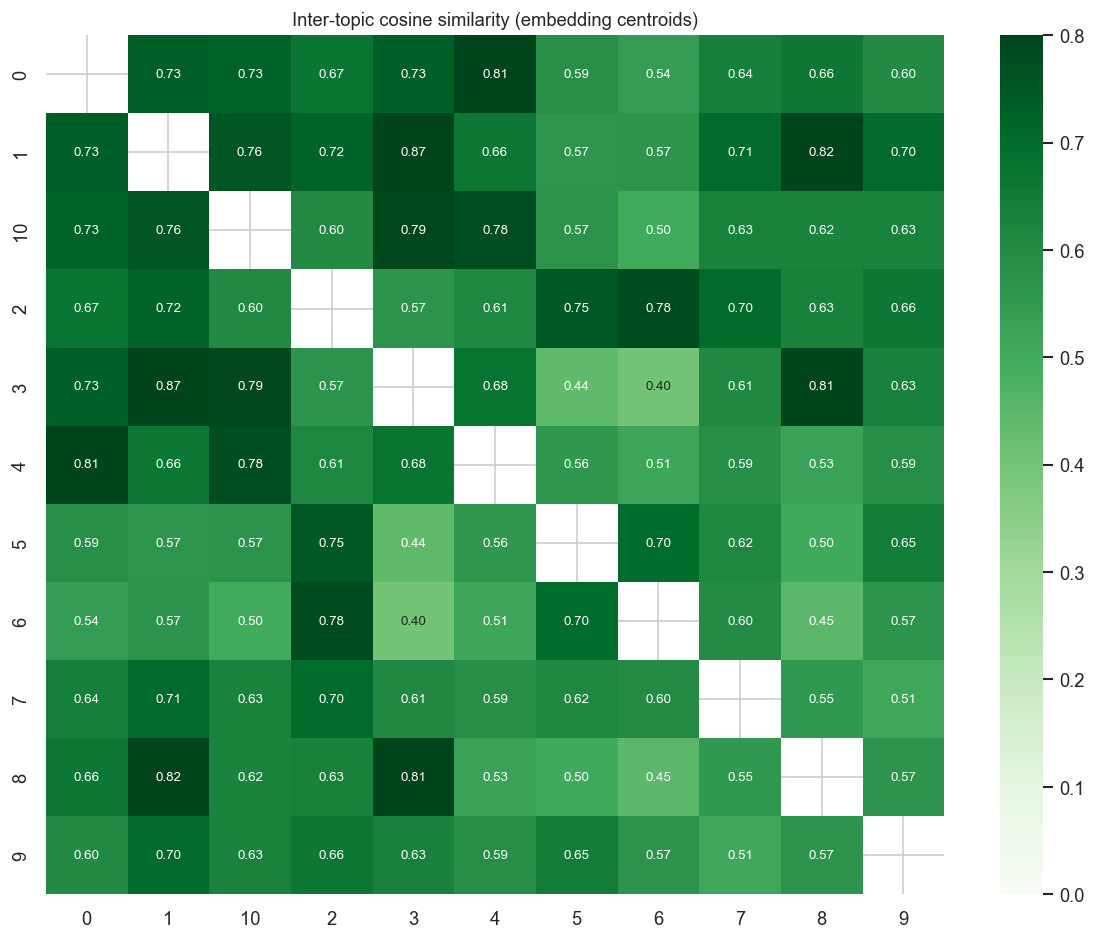


High-similarity pairs (sim > 0.45):
  Topic 0 <-> Topic 1:  0.734
  Topic 0 <-> Topic 10:  0.727
  Topic 0 <-> Topic 2:  0.670
  Topic 0 <-> Topic 3:  0.729
  Topic 0 <-> Topic 4:  0.813
  Topic 0 <-> Topic 5:  0.586
  Topic 0 <-> Topic 6:  0.542
  Topic 0 <-> Topic 7:  0.640
  Topic 0 <-> Topic 8:  0.661
  Topic 0 <-> Topic 9:  0.601
  Topic 1 <-> Topic 10:  0.756
  Topic 1 <-> Topic 2:  0.720
  Topic 1 <-> Topic 3:  0.870
  Topic 1 <-> Topic 4:  0.663
  Topic 1 <-> Topic 5:  0.568
  Topic 1 <-> Topic 6:  0.570
  Topic 1 <-> Topic 7:  0.706
  Topic 1 <-> Topic 8:  0.816
  Topic 1 <-> Topic 9:  0.704
  Topic 10 <-> Topic 2:  0.603
  Topic 10 <-> Topic 3:  0.791
  Topic 10 <-> Topic 4:  0.776
  Topic 10 <-> Topic 5:  0.572
  Topic 10 <-> Topic 6:  0.500
  Topic 10 <-> Topic 7:  0.626
  Topic 10 <-> Topic 8:  0.624
  Topic 10 <-> Topic 9:  0.625
  Topic 2 <-> Topic 3:  0.572
  Topic 2 <-> Topic 4:  0.613
  Topic 2 <-> Topic 5:  0.749
  Topic 2 <-> Topic 6:  0.780
  Topic 2 <-> Topic 7: 

In [17]:
# ── 13c-ii: Inter-topic cosine similarity heatmap ───────────────────────
# Pairs with similarity > 0.50 are flagged as potential merge candidates.

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

valid_topics = sorted(
    [t for t in df_model['topic_id'].unique() if t != -1],
    key=lambda x: str(x)
)

# Compute centroid for each topic from pre-computed embeddings
df_indexed = df_model.reset_index(drop=True)
centroids = {}
for tid in valid_topics:
    idx = df_indexed[df_indexed['topic_id'] == tid].index.tolist()
    centroids[tid] = embeddings[idx].mean(axis=0)

topic_labels = [str(t) for t in valid_topics]
centroid_matrix = np.array([centroids[t] for t in valid_topics])
sim_matrix = cos_sim(centroid_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(valid_topics), dtype=bool)
sns.heatmap(
    sim_matrix, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=topic_labels, yticklabels=topic_labels,
    mask=mask, vmin=0, vmax=0.8, ax=ax, annot_kws={'size': 8}
)
ax.set_title(
    'Inter-topic cosine similarity (embedding centroids)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('fig_topic_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHigh-similarity pairs (sim > 0.45):")
found = False
for i, ti in enumerate(valid_topics):
    for j, tj in enumerate(valid_topics):
        if j > i and sim_matrix[i, j] > 0.45:
            print(f"  Topic {ti} <-> Topic {tj}:  {sim_matrix[i, j]:.3f}")
            found = True
if not found:
    print('  None — all topic pairs below threshold.')


In [18]:
# ── 13c-iii: Topic size distribution ──────────────────────────────
MIN_CLUSTER_SIZE = 8  # HDBSCAN parameter used in final model

size_df = (
    df_model[df_model['topic_id'] != -1]
    .groupby('topic_id')
    .size()
    .reset_index(name='n_papers')
    .sort_values('n_papers')
    .reset_index(drop=True)
)
size_df['flag'] = size_df['n_papers'].apply(
    lambda n: '⚠ near boundary' if n <= MIN_CLUSTER_SIZE + 2 else ''
)
print(f"Topic size distribution  (min_cluster_size = {MIN_CLUSTER_SIZE})\n")
display(size_df)
print(f"\nTopics at or near boundary (n <= {MIN_CLUSTER_SIZE + 2}):")
flagged = size_df[size_df['flag'] != '']
if len(flagged):
    for _, row in flagged.iterrows():
        print(f"  Topic {row['topic_id']:>4s}  n={row['n_papers']}")
else:
    print('  None.')


Topic size distribution  (min_cluster_size = 8)



,topic_id,n_papers,flag
0,10,8,⚠ near boundary
1,9,9,⚠ near boundary
2,8,10,⚠ near boundary
3,7,11,
4,6,17,
5,5,22,
6,4,24,
7,3,25,
8,2,37,
9,1,51,



Topics at or near boundary (n <= 10):


ValueError: Unknown format code 's' for object of type 'int'

#### Topic Validation Decision Log

| Topic(s) | Action | Rationale |
|----------|--------|-----------|
| 0 (n=60) | **Keep — flag as broad cluster** | Spans executive compensation contracting and board/governance mechanisms. Acknowledged in results narrative; no model-level split applied to preserve methodological transparency. |
| 2 (n=37) | **Keep — flag as broad cluster** | Covers MA role/identity and digitalization of the finance function. Heterogeneous methodology profile noted in results. |
| 9 (n=9), 10 (n=8) | **Keep** | Both semantically coherent despite small size; merging would obscure distinct streams. |
| — | No further action | All other topics are coherent and within expected size bounds. |


---

## Step 14 — Visualizations

> **Note:** Visualizations reflect the original 11-topic BERTopic taxonomy (Topics 0–10). No manual splits are applied; Topics 0 and 2 appear as single clusters.

Four visualizations provide different perspectives on the topic structure:
- **14a** — volume ranking of topics
- **14b** — keyword weight profiles (what drives each topic)
- **14c** — spatial document map (semantic proximity)
- **14d** — temporal evolution of topics across 2021–2026


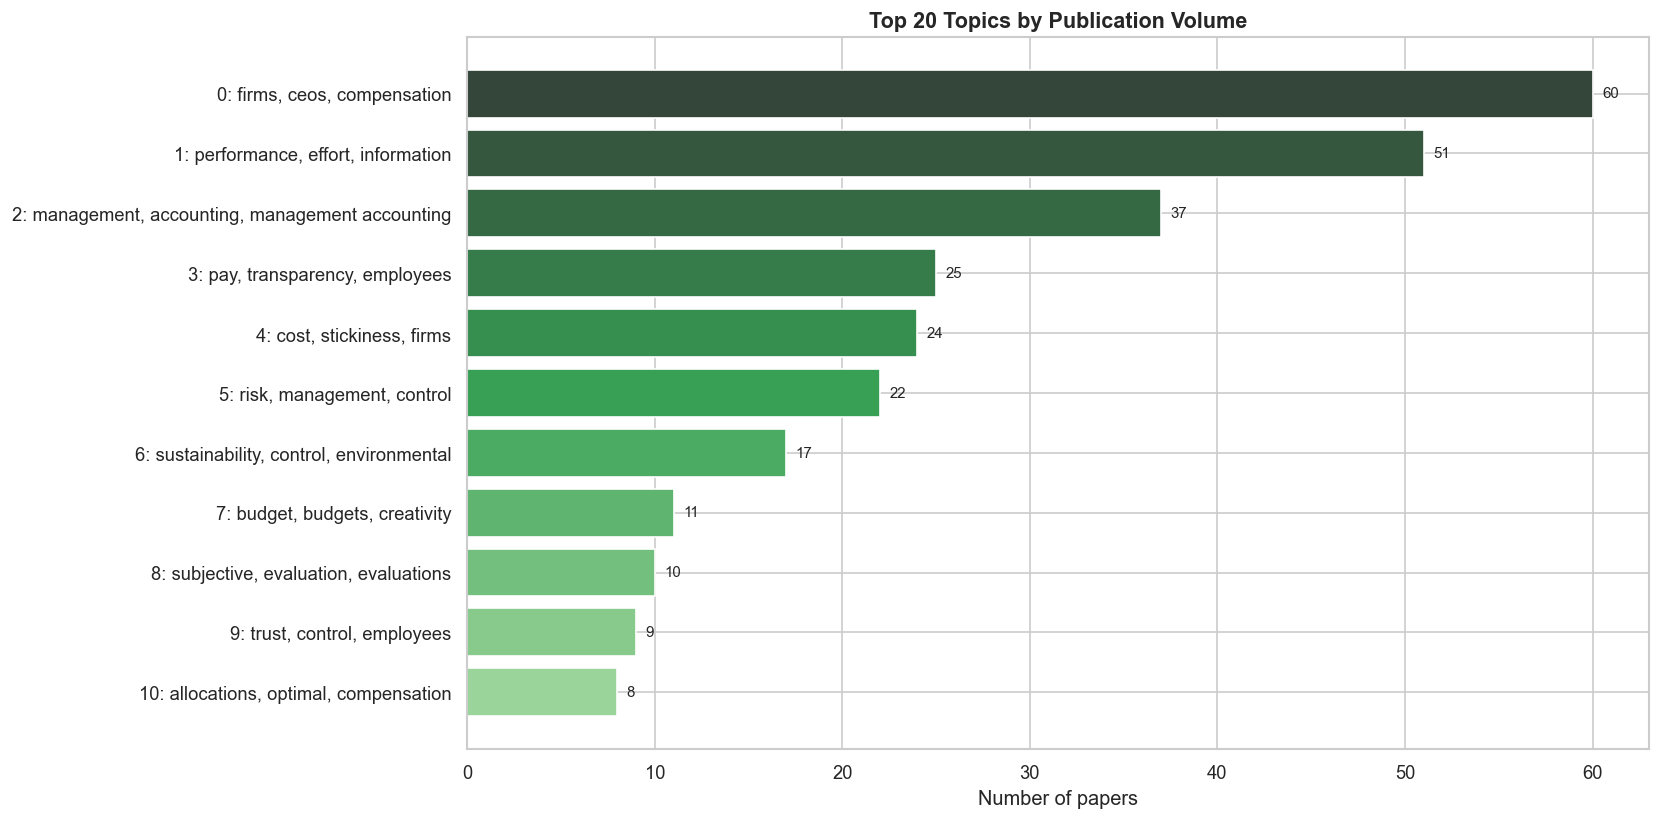

Saved fig_topic_barchart.png and .html


In [19]:
# ── 14a: Top 20 topics by paper count ─────────────────────────────────────────
top20 = topic_overview.head(20).copy()
top20["label"] = top20["Topic"].astype(str) + ": " + top20["top_keywords"].str.split(",").str[:3].str.join(",")

fig_bar, ax_bar = plt.subplots(figsize=(14, 7))
bars = ax_bar.barh(top20["label"][::-1], top20["Count"][::-1], color=sns.color_palette("Greens_d", len(top20)))
for bar in bars:
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width())}", va="center", fontsize=9)
ax_bar.set_title("Top 20 Topics by Publication Volume", fontsize=13, fontweight="bold")
ax_bar.set_xlabel("Number of papers")
ax_bar.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_topic_barchart.png", bbox_inches="tight")
plt.show()

# Interactive version
fig_bar_px = px.bar(
    top20,
    x="Count", y="label", orientation="h",
    title="Top 20 Topics by Publication Volume",
    labels={"Count": "Number of papers", "label": ""},
    color="Count", color_continuous_scale="Greens"
)
fig_bar_px.update_layout(yaxis={"categoryorder": "total ascending"})
fig_bar_px.write_html("fig_topic_barchart.html")
print("Saved fig_topic_barchart.png and .html")

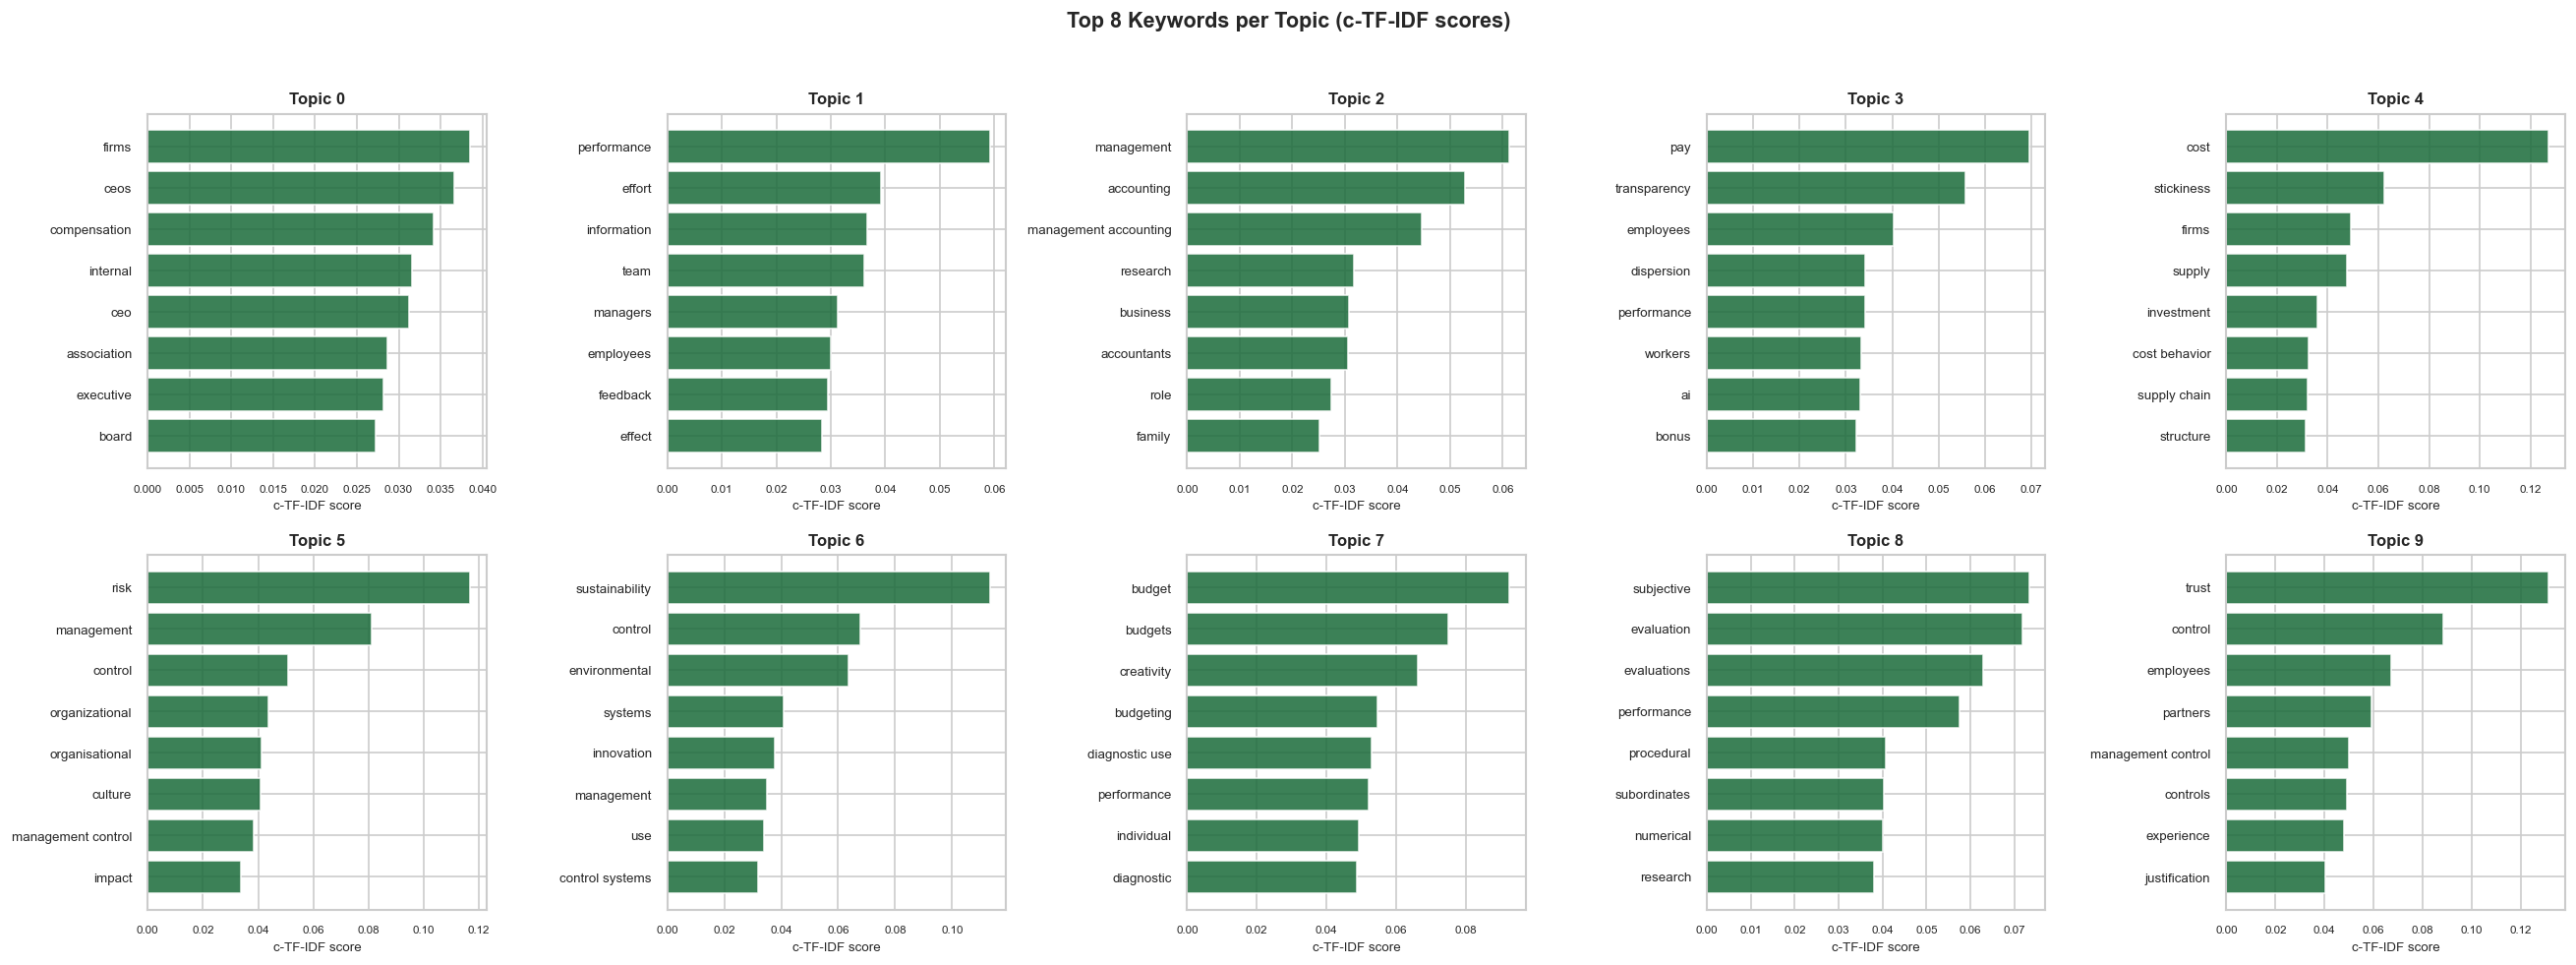

Saved fig_topic_keywords.png


In [20]:
# ── 14b: Keyword scores for top 10 topics (2×5 grid) ──────────────────────────
top10_ids = topic_overview.head(10)["Topic"].tolist()  # original integer topic IDs

fig_kw, axes_kw = plt.subplots(2, 5, figsize=(22, 8))
axes_kw = axes_kw.flatten()

for idx, topic_id in enumerate(top10_ids):
    try:
        words_scores = topic_model.get_topic(int(topic_id))[:8]
    except (ValueError, TypeError):
        words_scores = []
    if not words_scores:
        continue
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]
    ax = axes_kw[idx]
    bars_kw = ax.barh(words, scores, color="#1a6b3a", alpha=0.85)
    ax.set_title(f"Topic {topic_id}", fontsize=10, fontweight="bold")
    ax.set_xlabel("c-TF-IDF score", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)

# Hide any unused subplots
for j in range(len(top10_ids), len(axes_kw)):
    axes_kw[j].set_visible(False)

fig_kw.suptitle("Top 8 Keywords per Topic (c-TF-IDF scores)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_topic_keywords.png", bbox_inches="tight")
plt.show()
print("Saved fig_topic_keywords.png")


Computing 2D UMAP for visualization ...


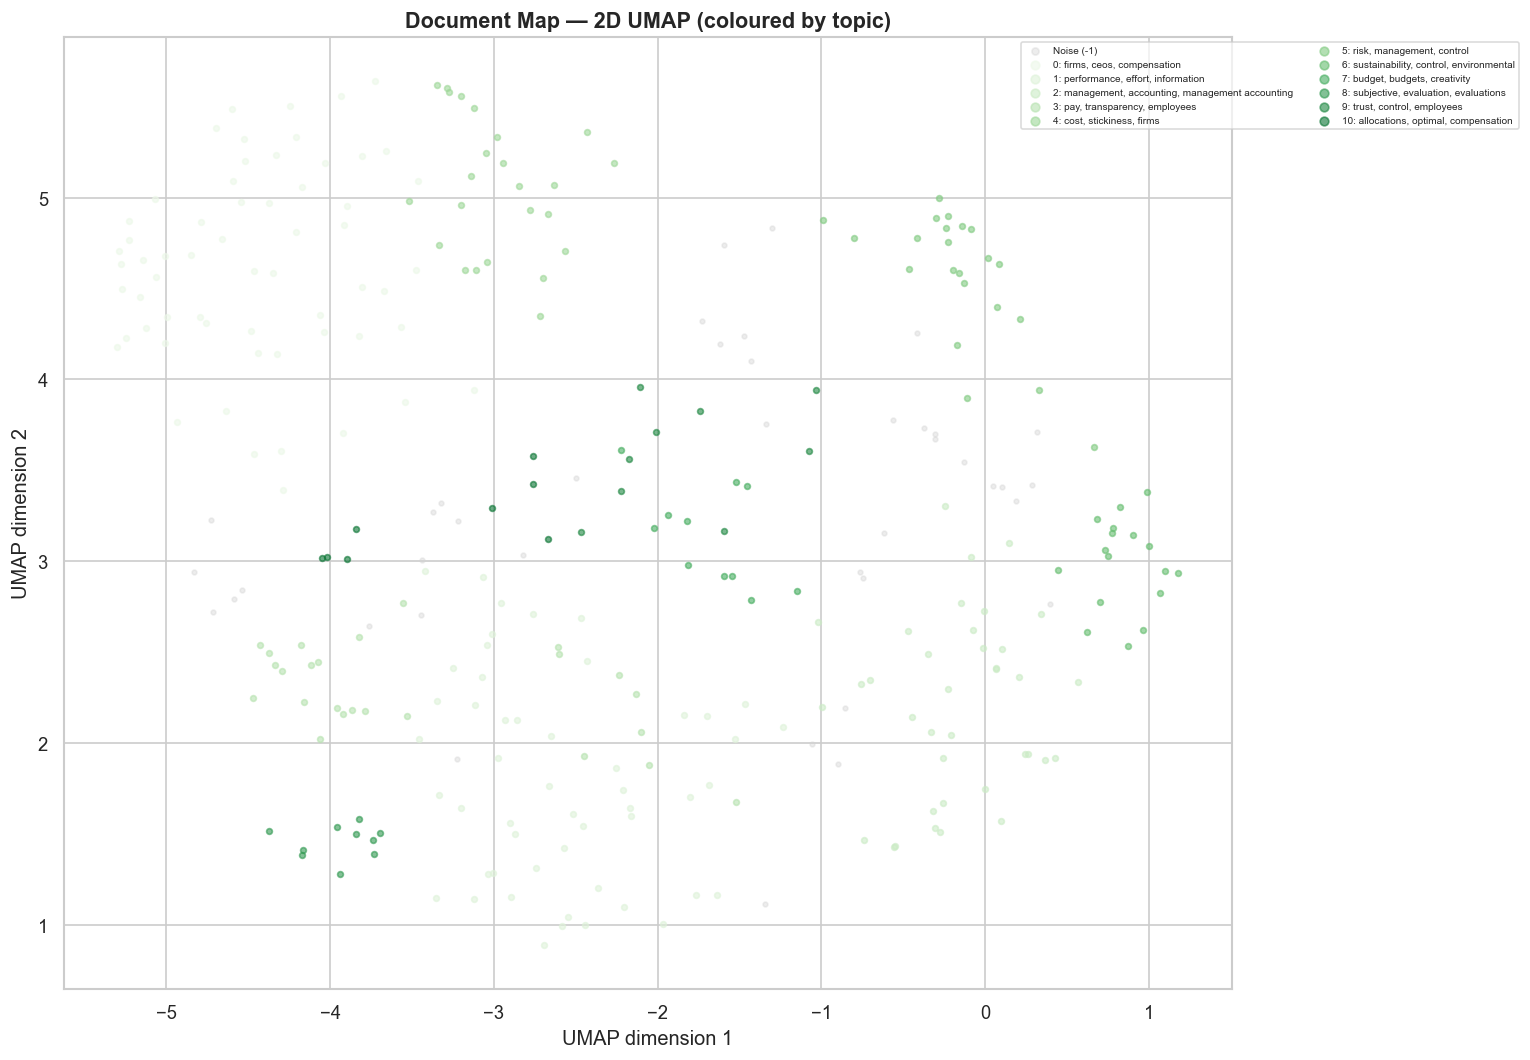

Saved fig_topic_map.png and .html


In [21]:
# ── 14c: 2D UMAP document map ──────────────────────────────────────────────────
# Run a separate 2-component UMAP purely for visualization (NOT used in modeling)
print("Computing 2D UMAP for visualization ...")
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.1,
               metric="cosine", random_state=42)
coords_2d = umap_2d.fit_transform(embeddings)

df_map = df_model[["Title", "Source title", "Year", "topic_id", "topic_keywords"]].copy()
df_map["umap_x"] = coords_2d[:, 0]
df_map["umap_y"] = coords_2d[:, 1]
df_map["topic_label"] = df_map["topic_id"].astype(str) + ": " + \
    df_map["topic_keywords"].str.split(",").str[:3].str.join(",")

# Static version
non_noise = df_map[df_map["topic_id"] != -1]
noise_pts = df_map[df_map["topic_id"] == -1]

fig_map, ax_map = plt.subplots(figsize=(13, 9))
palette = sns.color_palette("Greens", n_colors=min(20, df_map["topic_id"].nunique()))

ax_map.scatter(noise_pts["umap_x"], noise_pts["umap_y"],
               c="lightgrey", s=8, alpha=0.4, label="Noise (-1)", zorder=1)

for i, tid in enumerate(sorted(non_noise["topic_id"].unique())):
    subset = non_noise[non_noise["topic_id"] == tid]
    kws = ", ".join(get_top_keywords(tid, n=3).split(", "))
    ax_map.scatter(subset["umap_x"], subset["umap_y"],
                   s=12, alpha=0.6, label=f"{tid}: {kws}",
                   color=palette[i % 20], zorder=2)

ax_map.set_title("Document Map — 2D UMAP (coloured by topic)", fontsize=13, fontweight="bold")
ax_map.set_xlabel("UMAP dimension 1")
ax_map.set_ylabel("UMAP dimension 2")
ax_map.legend(fontsize=6, loc="upper right", ncol=2,
              framealpha=0.7, markerscale=1.5,
              bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.savefig("fig_topic_map.png", bbox_inches="tight")
plt.show()

# Interactive plotly version (hover shows title)
df_map_plot = df_map.copy()
df_map_plot["topic_str"] = df_map_plot["topic_id"].astype(str)

fig_map_px = px.scatter(
    df_map_plot,
    x="umap_x", y="umap_y",
    color="topic_str",
    hover_data={"Title": True, "Source title": True, "Year": True,
                "topic_keywords": True, "umap_x": False, "umap_y": False},
    title="Document Map — 2D UMAP (interactive)",
    labels={"umap_x": "UMAP 1", "umap_y": "UMAP 2", "topic_str": "Topic"},
    opacity=0.6,
    width=1100, height=750
)
fig_map_px.update_traces(marker_size=4)
fig_map_px.write_html("fig_topic_map.html")
print("Saved fig_topic_map.png and .html")

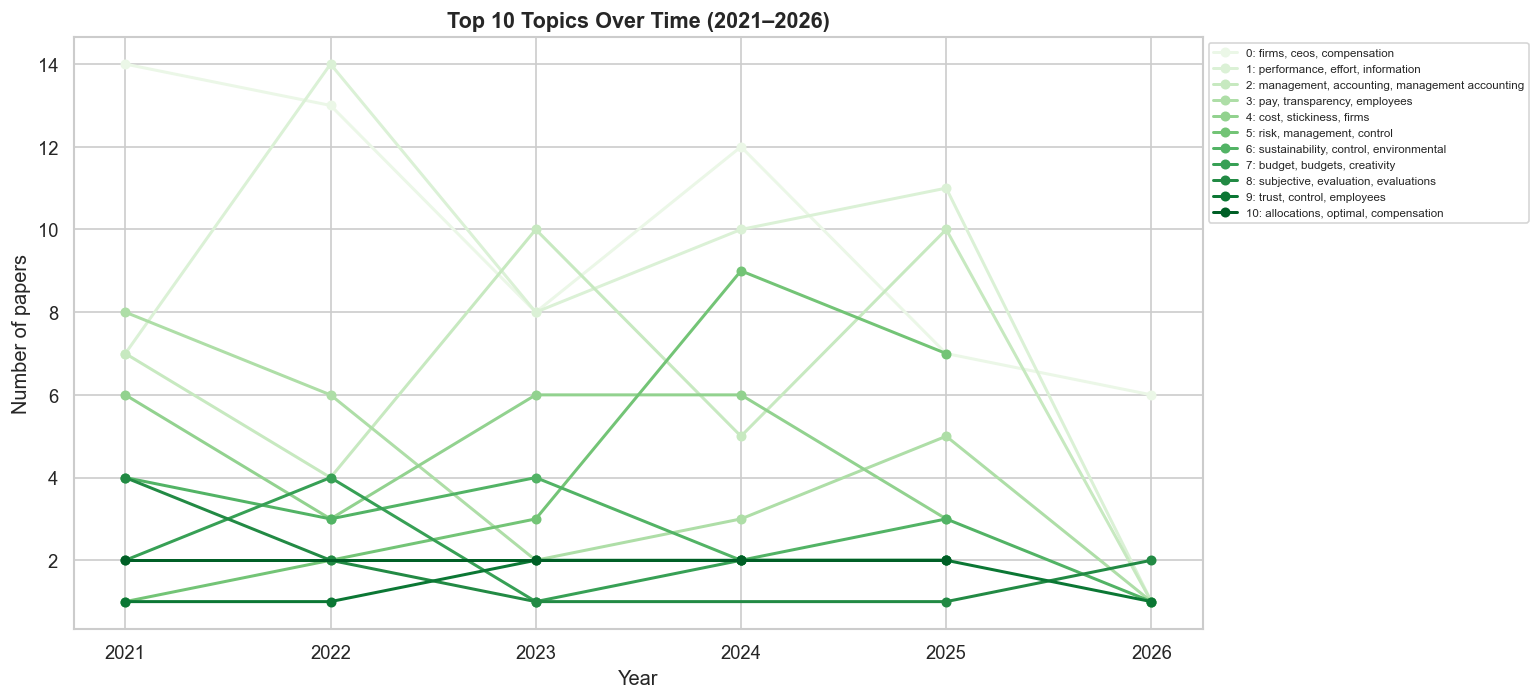

Saved fig_topics_over_time.png and .html


In [22]:
# ── 14d: Topics over time ──────────────────────────────────────────────────────
# All named topics from the revised taxonomy, ordered by paper count
top10_topic_ids = topic_overview["Topic"].tolist()

if "Year" in df_model.columns and df_model["Year"].notna().any():
    # Manual groupby (more reliable than BERTopic's built-in for publication years)
    tot = (
        df_model[df_model["topic_id"].isin(top10_topic_ids)]
        .groupby(["Year", "topic_id"])
        .size()
        .reset_index(name="count")
    )
    tot["Year"] = tot["Year"].astype(int)
    tot["topic_label"] = tot["topic_id"].apply(
        lambda t: f"{t}: {get_top_keywords(t, n=3)}"
    )

    # Static version
    fig_tot, ax_tot = plt.subplots(figsize=(13, 6))
    palette_tot = sns.color_palette("Greens", n_colors=len(top10_topic_ids))
    for i, tid in enumerate(top10_topic_ids):
        subset = tot[tot["topic_id"] == tid].sort_values("Year")
        lbl = f"{tid}: {get_top_keywords(tid, n=3)}"
        ax_tot.plot(subset["Year"], subset["count"],
                    marker="o", linewidth=1.8, markersize=5,
                    label=lbl, color=palette_tot[i])
    ax_tot.set_title("Top 10 Topics Over Time (2021–2026)", fontsize=13, fontweight="bold")
    ax_tot.set_xlabel("Year")
    ax_tot.set_ylabel("Number of papers")
    ax_tot.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax_tot.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig("fig_topics_over_time.png", bbox_inches="tight")
    plt.show()

    # Interactive version
    fig_tot_px = px.line(
        tot.sort_values(["topic_label", "Year"]),
        x="Year", y="count", color="topic_label",
        markers=True,
        title="Top 10 Topics Over Time (2021–2026)",
        labels={"count": "Papers", "topic_label": "Topic"},
        width=1100, height=600
    )
    fig_tot_px.write_html("fig_topics_over_time.html")
    print("Saved fig_topics_over_time.png and .html")
else:
    print("'Year' column not available — skipping topics-over-time chart.")